In [280]:

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


from datetime import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression

rng = np.random.default_rng() # To generate random numbers
options={"disp": False} # To not get verbose from minimize function

## Functions for algorithms

First I define some functions that will be used later in all algorithms.

In [281]:
def sig(z):
    """ Sigmoid function """
    return 1 / (1 + np.exp(-z))

In [282]:
# NOTE TO DO : put in general algorithm function that if radius == NA then this is not done.
def project_onto_l2_ball(x,radius):
    """ Euclidean projection onto L2 ball"""
    norm = np.linalg.norm(x)
    if norm <= radius:
        return x
    return x * radius/norm

## Online Gradient Descent

In [283]:
def online_gd(n, d, data_y, data_x, B):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B: float
        Radius of the L2 ball constraint for the parameter vector beta"""

    # Start time
    start_time = datetime.now()

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    gradients_sum = np.zeros(d) # Gradient sum: g_s from s=1 to t - 1 (it gets updated at the end of the round)
    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        betas[t] = project_onto_l2_ball(beta_tilde,B)

        # Issue prediction
        #y_hat = sig(np.inner(betas[t],xt)) commented out because its never used so there's no need to calculate it

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        gradients_sum += gradient

        # Suffer loss
        loss[t] = np.log(1+np.exp(-yt*np.inner(xt,betas[t])))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0

        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

    # Store endtime
    end_time = datetime.now()
    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : sum(loss)
    }


## AIOLI

In [284]:
def AIOLI(n, d, data_y, data_x, B, X):
    """AIOLI
    This is the AIOLI using the reduced version of the loss function.

    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    B: float
        Radius of the L2 ball constraint for the parameter vector beta
    X: float
        Radius of the L2 ball constraint for the feature vector x"""
    # Record start time
    start_time = datetime.now()

    # Initialize vectors for storage
    betas = np.zeros((n, d))
    ys = np.zeros(n)
    y_hats = np.zeros(n)
    loss = np.zeros(n)
    etas = np.zeros(n)
    gradients = np.zeros((n, d))
    sum_loss = 0
    reg_lambda = 1 / (B**2)

    # Keep sums for loss functions
    gradients_sum = 0
    first_sum  = 0
    etas_gradients = 0
    convergence = 0

    # Define function to minimize for AIOLI
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + np.inner(np.inner(b,etas_gradients), b)
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result

    # Run Algorithm
    for t in range(n):
        # Get context vector
        xt = data_x[t]

        # Update beta parameter
        if t == 0: # Initialize to 0 for first round
            beta_tilde = np.zeros(d)
        else:
            x0 = np.zeros(d) # Random initializer for minimizing algorithm, Completely arbitrary for now
            result = minimize(parameter_function_AIOLI, x0, method = "l-bfgs-b", args=(xt, reg_lambda,first_sum, etas_gradients))
            beta_tilde = result.x
            convergence += result.success

        # Project beta onto set
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Generate prediction
        y_hats[t] = np.inner(betas[t],xt)

        # Observe true y from data
        ys[t] = data_y[t]

        # Estimate eta
        etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

        # Compute gradient
        gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

        # Compute elements for loss function
        gradients_sum += gradients[t]
        first_sum += gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
        etas_gradients += (etas[t]/2)*np.inner(gradients[t],gradients[t])

        # Suffer loss
        loss[t] = np.log(1+np.exp(-ys[t]*np.inner(xt,betas[t])))

        # Update sum of losses
        sum_loss += loss[t]
    # for loop ends

    end_time = datetime.now()
    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : sum_loss,
        "convergence" : convergence
    }


## Logistic Regression

In [317]:
def classic_logistic_regression(data_x,data_y): #Using scikit learn
    start_time = datetime.now()
    # Initialize the model
    logreg = LogisticRegression(penalty=None)

    # fit the model with data
    logreg.fit(data_x,data_y)
    coefficients = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
    betas = np.exp(coefficients) / ( 1+ np.exp(coefficients)) # exponent to pass it back to the scale of the data since now its in scale of the log odds.

    loss = sum(np.logaddexp(0,-data_y*np.inner(data_x,betas)))
    end_time = datetime.now()
    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss
    }

### Testing it

In [286]:
n =100
mean = [rng.normal(20,2,1).item(), rng.normal(10,4,1).item(), rng.normal(0,5,1).item()]
cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
d = np.shape(cov)[1]

y = np.random.binomial(n=1, p=rng.uniform(0,1,1).round(2), size=n)

x = np.random.multivariate_normal(mean, cov, size = n)

In [307]:
# Initialize the model
logreg = LogisticRegression(penalty=None, C=np.inf)

# fit the model with data
logreg.fit(data_x,data_y)

betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements

loss = sum(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [313]:
logreg

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [288]:
results_clg = classic_logistic_regression(x,y)

# Testing algorithm functions

## Test performance of algorithms: runtime and loss

In [318]:
runs = 20
n = 100 # Sample size, equivalent to T in online learning
results_all = []

# All parameters for data generation and for the upper bounds of beta and context vector are just random numbers

for i in range(runs):

    mean = [rng.normal(20,2,1).item(), rng.normal(10,4,1).item(), rng.normal(0,5,1).item()]
    cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
    d = np.shape(cov)[1]

    y = np.random.binomial(n=1, p=rng.uniform(0.1,0.9,1).round(2), size=n)

    x = np.random.multivariate_normal(mean, cov, size = n)

    ogd = online_gd(n = n,d = d,data_y = y,data_x = x,B = 30)
    ai  = AIOLI(n = n,d = d,data_y = y,data_x = x, B = 30, X = 35)
    classic_lg = classic_logistic_regression(data_x = x, data_y = y)

    results_all.append({
        "algorithm": "OGD",
        "run": i,
        "runtime": ogd["runtime"],
        "loss": ogd["Total_Loss"],
        "convergence": 1
    })

    results_all.append({
        "algorithm": "AIOLI",
        "run": i,
        "runtime": ai["runtime"],
        "loss": ai["Total_Loss"],
        "convergence": ai["convergence"]
    })

    results_all.append({
        "algorithm": "Classical_LG",
        "run": i,
        "runtime": classic_lg["runtime"],
        "loss": classic_lg["Total_Loss"],
        "convergence": 1
    })

final_results = pd.DataFrame(results_all)


In [319]:
final_results.groupby("algorithm")[["runtime", "loss"]].mean()

,runtime,loss
algorithm,,
AIOLI,0.335013,36.358656
Classical_LG,0.011318,35.005125
OGD,0.001993,35.697080


In [312]:
final_results.groupby("algorithm")[["convergence"]].mean()*100/n

,convergence
algorithm,
AIOLI,99.0
Classical_LG,1.0
OGD,1.0


# Ignore from here on, it's simply code to test some functions/debugging

## Tests

In [292]:
etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
xt = np.array([1,2,3])
betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
reg_lambda = 0.3
gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
b = np.array([1,2,3])
sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [293]:
diff = b - betas
inner_prod = np.sum(gradients * diff,axis = 1)
np.sum(np.sum(etas)/2 * inner_prod**2)

np.float64(1879.2751262122324)

In [294]:
x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [295]:
diff = b - betas
gs_bs = np.sum(gradients * diff,axis = 1)
quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)

l_hat = sum_loss + np.sum(gs_bs) + quadratic

l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

np.float64(1843.397625091321)

## Generate data

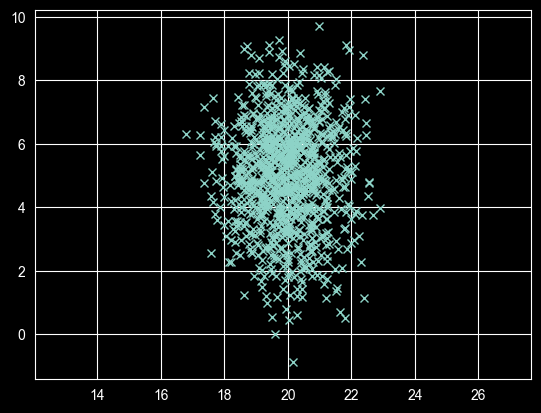

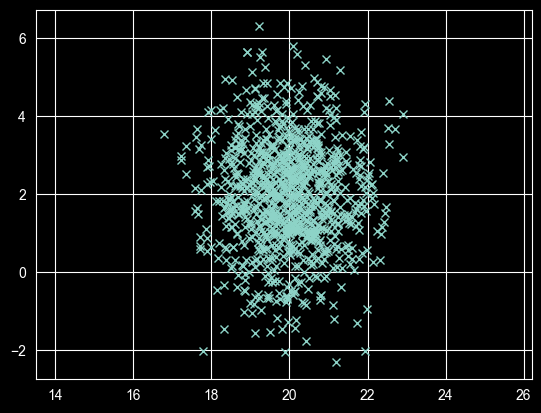

In [296]:
n = 1000

mean = [20, 5, 2]
cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
d = np.shape(cov)[1]
y = np.random.binomial(n=1, p=0.3, size=n)

x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
plt.plot(x1, x2, 'x')
plt.axis('equal')
plt.show()

plt.plot(x1, x3, 'x')
plt.axis('equal')
plt.show()


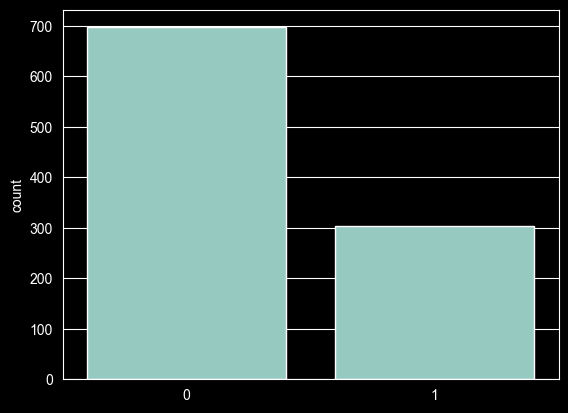

In [297]:
x = np.random.multivariate_normal(mean, cov, size = n)
sns.countplot(x=y)
plt.show()


In [298]:
np.log(1000)

np.float64(6.907755278982137)